In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [99]:
df =pd.read_csv("UsedCarPrice_Prediction.csv")

In [100]:
df.head(6)

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
5,maruti alto k10,2018,petrol,23534,335299,noida,1055,hatchback,NaN,vxi (o) amt,...,1,343212,439056.0,great,2021-04-13T05:55:16.99,True,7788,50295,False,False


In [102]:
df=df[["yr_mfr","fuel_type","kms_run","sale_price","body_type","transmission","make","total_owners","broker_quote"]]

In [103]:
print(df.columns)

Index(['yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'body_type',
       'transmission', 'make', 'total_owners', 'broker_quote'],
      dtype='str')


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   yr_mfr        7400 non-null   int64
 1   fuel_type     7400 non-null   str  
 2   kms_run       7400 non-null   int64
 3   sale_price    7400 non-null   int64
 4   body_type     7297 non-null   str  
 5   transmission  6844 non-null   str  
 6   make          7400 non-null   str  
 7   total_owners  7400 non-null   int64
 8   broker_quote  7400 non-null   int64
dtypes: int64(5), str(4)
memory usage: 708.5 KB


In [105]:
df.describe()

,yr_mfr,kms_run,sale_price,total_owners,broker_quote
count,7400.000000,7400.000000,7.400000e+03,7400.000000,7.400000e+03
mean,2013.885676,62624.520000,4.548892e+05,1.327297,4.322044e+05
std,3.087613,43532.042371,2.827023e+05,0.579798,2.880316e+05
min,1996.000000,60.000000,0.000000e+00,1.000000,0.000000e+00
25%,2012.000000,31885.250000,2.811740e+05,1.000000,2.526612e+05
50%,2014.000000,55765.000000,3.824490e+05,1.000000,3.611445e+05
75%,2016.000000,84184.000000,5.401490e+05,2.000000,5.260180e+05
max,2021.000000,996609.000000,3.866000e+06,6.000000,3.250000e+06


In [106]:
df.shape

(7400, 9)

In [107]:
df.isnull().sum()

yr_mfr            0
fuel_type         0
kms_run           0
sale_price        0
body_type       103
transmission    556
make              0
total_owners      0
broker_quote      0
dtype: int64

In [108]:
df["body_type"] = df["body_type"].fillna(df["body_type"].mode()[0])
df["transmission"] = df["transmission"].fillna(df["transmission"].mode()[0])

In [109]:
df.isnull().sum()

yr_mfr          0
fuel_type       0
kms_run         0
sale_price      0
body_type       0
transmission    0
make            0
total_owners    0
broker_quote    0
dtype: int64

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   yr_mfr        7400 non-null   int64
 1   fuel_type     7400 non-null   str  
 2   kms_run       7400 non-null   int64
 3   sale_price    7400 non-null   int64
 4   body_type     7400 non-null   str  
 5   transmission  7400 non-null   str  
 6   make          7400 non-null   str  
 7   total_owners  7400 non-null   int64
 8   broker_quote  7400 non-null   int64
dtypes: int64(5), str(4)
memory usage: 710.8 KB


In [111]:
df.dtypes

yr_mfr          int64
fuel_type         str
kms_run         int64
sale_price      int64
body_type         str
transmission      str
make              str
total_owners    int64
broker_quote    int64
dtype: object

In [114]:
df = pd.get_dummies(df,columns=["fuel_type","body_type","transmission","make"], drop_first=True)

In [113]:
df.head()


,yr_mfr,fuel_type,kms_run,sale_price,body_type,transmission,make,total_owners,broker_quote
0,2015,petrol,8063,386399,hatchback,manual,maruti,2,397677
1,2016,petrol,23104,265499,hatchback,manual,maruti,1,272935
2,2017,petrol,23402,477699,hatchback,manual,hyundai,1,469605
3,2013,diesel,39124,307999,hatchback,manual,maruti,1,294262
4,2015,petrol,22116,361499,hatchback,manual,hyundai,1,360716


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Columns: 224 entries, yr_mfr to model_zs ev
dtypes: bool(219), int64(5)
memory usage: 1.8 MB


In [115]:
X=df.drop("sale_price",axis=1)
y=df["sale_price"]

In [116]:
df.isnull().sum()

yr_mfr                    0
kms_run                   0
sale_price                0
total_owners              0
broker_quote              0
fuel_type_electric        0
fuel_type_petrol          0
fuel_type_petrol & cng    0
fuel_type_petrol & lpg    0
body_type_luxury sedan    0
body_type_luxury suv      0
body_type_sedan           0
body_type_suv             0
transmission_manual       0
make_bmw                  0
make_chevrolet            0
make_datsun               0
make_fiat                 0
make_ford                 0
make_honda                0
make_hyundai              0
make_isuzu                0
make_jaguar               0
make_jeep                 0
make_kia                  0
make_mahindra             0
make_mahindra renault     0
make_maruti               0
make_mercedes benz        0
make_mg                   0
make_mitsubishi           0
make_nissan               0
make_opel                 0
make_renault              0
make_skoda                0
make_ssangyong      

In [117]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,random_state=42)

In [118]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5920, 39)
(1480, 39)
(5920,)
(1480,)


In [119]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [120]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](39,)","[ 793.43, -0.01,3363.05,...,3908.67,4829.32, 144.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](39,)","['yr_mfr','kms_run','total_owners',...,'make_toyota','make_volkswagen', 'make_volvo']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.509e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,39
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [121]:
y_pred=model.predict(X_test)

In [122]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9642669515060411
MAE: 26225.741992852727
MSE: 2487543142.1648974
RMSE: 49875.27586053933


In [123]:
res=pd.DataFrame({"Actual Price":y_test,"Predicted Price":y_pred})
res.head(10)

,Actual Price,Predicted Price
4698,367499,357349.721354
5058,299699,319601.141729
7318,404399,391549.566154
169,238199,224393.477061
1952,397499,428875.798001
2375,235999,247993.920982
4475,417099,419632.052438
1656,216000,156127.714873
2168,577799,538253.719940
4019,519999,545021.581284


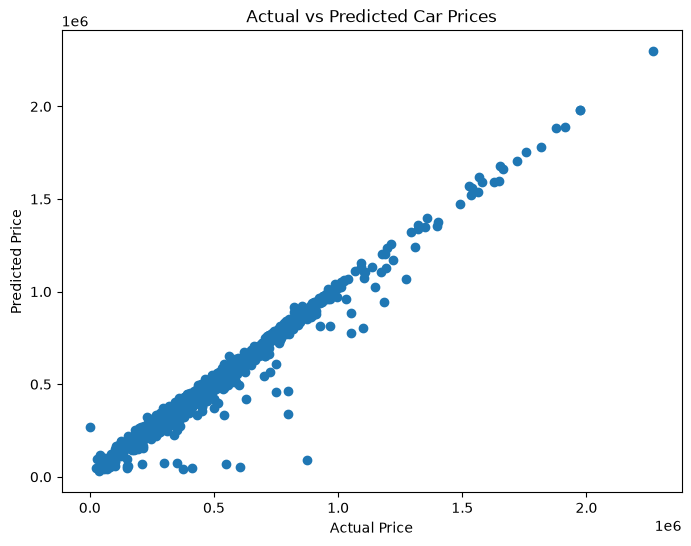

In [124]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [125]:
pickle.dump(model, open("UsedCarMODEL.pkl","wb"))